Загрузка датасета

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('../data/Onlineretail.xlsx')

Обзор датасета

In [107]:
print(df.head())
df.info()
print(df.describe())
df.isna().sum()

  invoiceno stockcode                          description  quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          invoicedate  unitprice  customerid         country  revenue  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom    15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom    22.00   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34   

      month  
0  December  
1  December  
2  December  
3  December  
4  December  
<class 'pandas.DataFrame'>
RangeIndex: 54190

invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135080
country             0
revenue             0
month               0
dtype: int64

Переименование столбцов

In [108]:
df.columns = df.columns.str.lower()

Поиск отрицательных и равных нулю значений

In [109]:
print(df[df['quantity'] <= 0])
print(df[df['unitprice'] < 0])
print(df[df['unitprice'] == 0])
print(df[df['unitprice'] > 30000])

       invoiceno stockcode                       description  quantity  \
141      C536379         D                          Discount        -1   
154      C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235      C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236      C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237      C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   
...          ...       ...                               ...       ...   
540449   C581490     23144   ZINC T-LIGHT HOLDER STARS SMALL       -11   
541541   C581499         M                            Manual        -1   
541715   C581568     21258        VICTORIAN SEWING BOX LARGE        -5   
541716   C581569     84978  HANGING HEART JAR T-LIGHT HOLDER        -1   
541717   C581569     20979     36 PENCILS TUBE RED RETROSPOT        -5   

               invoicedate  unitprice  customerid         country  revenue  \
141    2010-12-01 09:41:00      2

Выделяющиеся коды товара и работа с ними

In [110]:
print(df['stockcode'][df['stockcode'].str.len() > 8].unique())
print(df['stockcode'][df['stockcode'].str.len() < 5].unique())

['BANK CHARGES' 'AMAZONFEE' 'gift_0001_40' 'gift_0001_50' 'gift_0001_30'
 'gift_0001_20' 'DCGSSGIRL' 'gift_0001_10' 'DCGS0066P']
['POST' 'D' 'C2' 'DOT' 'M' 'S' 'm' 'PADS' 'B' 'CRUK']


In [111]:
print(df[df['stockcode'] == 'POST'])
print(df[df['stockcode'] == 'D'])
print(df[df['stockcode'] == 'C2'])
print(df[df['stockcode'] == 'DOT'])
print(df[df['stockcode'] == 'M'])
print(df[df['stockcode'] == 'S'])
print(df[df['stockcode'] == 'm'])
print(df[df['stockcode'] == 'PADS'])
print(df[df['stockcode'] == 'B'])
print(df[df['stockcode'] == 'CRUK'])
print(df[df['stockcode'] == 'BANK CHARGES'].head())
print(df[df['stockcode'] == 'AMAZONFEE'].head())
print(df[df['stockcode'].str.contains('gift', na=False)].head())

       invoiceno stockcode description  quantity         invoicedate  \
45        536370      POST     POSTAGE         3 2010-12-01 08:45:00   
386       536403      POST     POSTAGE         1 2010-12-01 11:27:00   
1123      536527      POST     POSTAGE         1 2010-12-01 13:04:00   
5073      536840      POST     POSTAGE         1 2010-12-02 18:27:00   
5258      536852      POST     POSTAGE         1 2010-12-03 09:51:00   
...          ...       ...         ...       ...                 ...   
541198    581493      POST     POSTAGE         1 2011-12-09 10:10:00   
541216    581494      POST     POSTAGE         2 2011-12-09 10:13:00   
541730    581570      POST     POSTAGE         1 2011-12-09 11:59:00   
541767    581574      POST     POSTAGE         2 2011-12-09 12:09:00   
541768    581578      POST     POSTAGE         3 2011-12-09 12:16:00   

        unitprice  customerid      country  revenue     month  
45           18.0     12583.0       France     54.0  December  
386    

Добавление необходимых для анализа столбцов и очистка от не товаров

In [112]:
df['revenue'] = df['quantity'] * df['unitprice']
df['month'] = df['invoicedate'].dt.month_name()
df2 = df.copy()
df2 = df2[~df2['stockcode'].isin(['POST', 'D', 'C2', 'DOT', 'M', 'S', 'm', 'PADS', 'B', 'CRUK',
                                  'BANK CHARGES', 'AMAZONFEE', 'gift_0001_40',
                                  'gift_0001_50', 'gift_0001_30', 'gift_0001_20'])]

Работа со столбцом 'description'

In [113]:
descriptions = (df2.groupby('description', dropna=False).agg(
    rows = ('description', 'size'),
    total_revenue = ('revenue', 'sum'),
    min_quantity = ('quantity', 'min'),
    max_quantity = ('quantity', 'max'),
    avg_quantity = ('quantity', 'mean'),
    min_price = ('unitprice', 'min'),
    max_price = ('unitprice', 'max'),
    avg_price = ('unitprice', 'mean')
)
).sort_values('rows', ascending=False).reset_index()

print(descriptions['description'][(descriptions['rows'] < 20) & \
                                  (descriptions['description'].str.len() < 18) & \
                                    ((descriptions['total_revenue'] > 200) | \
                                     (descriptions['total_revenue'] < -200))].unique(), '\n')
print(descriptions['description'][(descriptions['rows'] < 20) & \
                                  (descriptions['description'].str.len() < 18)].unique())

['SPACEBOY WALL ART' 'BUNTING , SPOTTY ' 'RAIN PONCHO ' 'NEWSPAPER STAND'] 

['adjustment' 'POSY CANDY BAG' 'PACKING CHARGE' 'WRAP RED DOILEY'
 'FLOWERS TILE HOOK' 'Damaged' 'WRAP CAROUSEL' 'WHITE TISSUE REAM'
 'FAN BLACK FRAME ' 'SPACEBOY WALL ART' 'GIRLS PARTY BAG'
 'DAISY HAIR COMB' 'BLUE DAISY MOBILE' 'PET MUG, GOLDFISH'
 'IVY HEART WREATH' 'BOYS PARTY BAG' 'VIP HOLIDAY PURSE' 'GOLD WASHBAG'
 'thrown away' 'GOLD WINE GOBLET' 'Found' 'FROG SOCK PUPPET' 'amazon'
 'WRAP FOLK ART' 'THE KING GIFT BAG' 'BEACH HUT MIRROR' 'TUMBLER, BAROQUE'
 'BUNTING , SPOTTY ' '??' 'Amazon' 'BLUE HOLE PUNCH' 'CANDY SPOT BUNNY'
 'ALUMINIUM HEART' 'RAIN PONCHO ' 'dotcom' 'wet damaged' 'NEWSPAPER STAND'
 'GOLD TEDDY BEAR' 'RIVIERA NECKLACE' 'ebay' 'BLUE TILED TRAY' 'damages?'
 'CLAM SHELL LARGE' 'WRAP, CAROUSEL' 'DONKEY TAIL GAME ' 'smashed'
 'AMAZON' 'CHECK' 'test' 'missing' 'mailout' 'wet pallet' 'wet rusty'
 'taig adjust' 'mixed up' 'returned' 'rusty throw away' 'wet/rusty'
 'sold as 1' 'stock check' 'Do

Ключевой анализ

In [114]:
best_month = (df.groupby('month').agg({'revenue': 'sum', 'quantity': 'sum'})
                                      .reset_index().sort_values('revenue', ascending=False))
print(best_month, '\n')
print(best_month['revenue'].sum())

        month      revenue  quantity
9    November  1461756.250    740286
2    December  1182625.030    568561
10    October  1070704.670    570532
11  September  1019687.622    549817
8         May   723333.510    380391
6        June   691123.120    341623
7       March   683267.080    351872
1      August   682680.510    406199
5        July   681300.111    391116
4     January   560000.260    308966
3    February   498062.650    277989
0       April   493207.121    289098 

9747747.934


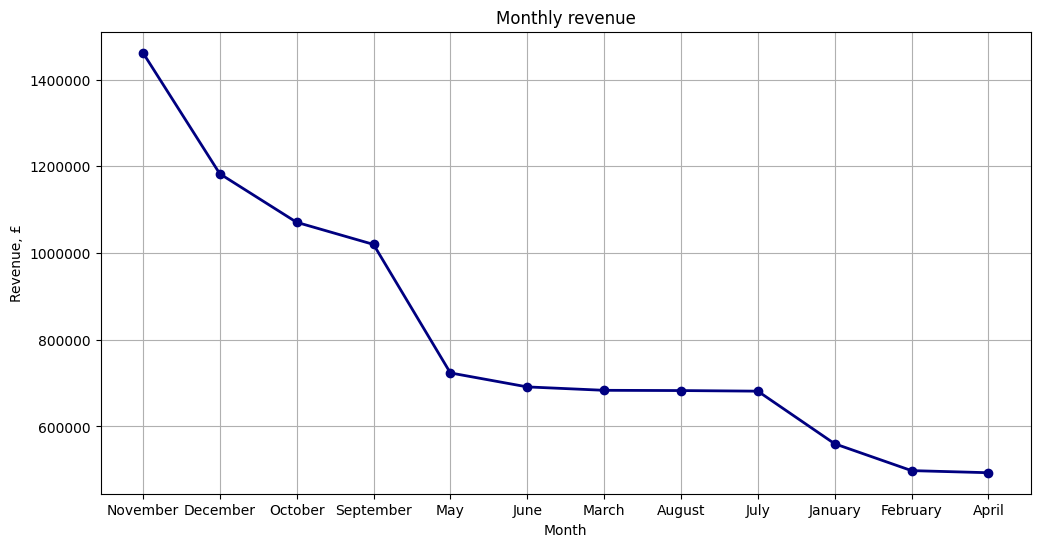

In [115]:
plt.figure(figsize=(12, 6))
plt.plot(best_month['month'], best_month['revenue'], marker='o', color='navy', linewidth=2)
plt.title('Monthly revenue')
plt.xlabel('Month')
plt.ylabel('Revenue, £')
plt.ticklabel_format(axis='y', style='plain')
plt.grid(True)
plt.show()

In [116]:
countries_revenue = df.groupby('country')['revenue'].sum().reset_index()\
    .sort_values('revenue', ascending=False).reset_index()
countries_revenue.drop(columns=['index'], inplace=True)
print(countries_revenue.head(10))
print(countries_revenue)

          country      revenue
0  United Kingdom  8187806.364
1     Netherlands   284661.540
2            EIRE   263276.820
3         Germany   221698.210
4          France   197403.900
5       Australia   137077.270
6     Switzerland    56385.350
7           Spain    54774.580
8         Belgium    40910.960
9          Sweden    36595.910
                 country      revenue
0         United Kingdom  8187806.364
1            Netherlands   284661.540
2                   EIRE   263276.820
3                Germany   221698.210
4                 France   197403.900
5              Australia   137077.270
6            Switzerland    56385.350
7                  Spain    54774.580
8                Belgium    40910.960
9                 Sweden    36595.910
10                 Japan    35340.620
11                Norway    35163.460
12              Portugal    29367.020
13               Finland    22326.740
14       Channel Islands    20086.290
15               Denmark    18768.140
16           

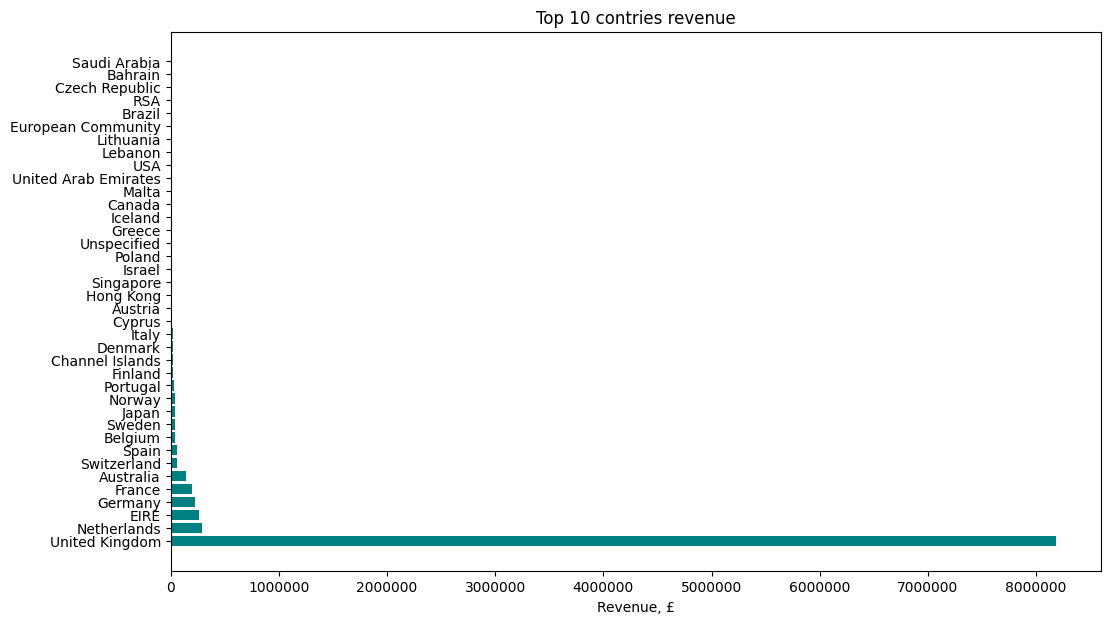

In [117]:
plt.figure(figsize=(12, 7))
plt.barh(countries_revenue['country'], countries_revenue['revenue'], color='teal')
plt.title('Top 10 contries revenue')
plt.xlabel('Revenue, £')
plt.ticklabel_format(axis='x', style='plain')
plt.show()

In [118]:
top_prods = df2.groupby('description').agg({'revenue': 'sum', 'quantity': 'sum'}).reset_index()\
    .sort_values('revenue', ascending=False).reset_index()
top_prods.drop(columns=['index'], inplace=True)
print(top_prods.head(10))

                          description    revenue  quantity
0            REGENCY CAKESTAND 3 TIER  164762.19     13033
1  WHITE HANGING HEART T-LIGHT HOLDER   99668.47     35317
2                       PARTY BUNTING   98302.98     18022
3             JUMBO BAG RED RETROSPOT   92356.03     47363
4                  RABBIT NIGHT LIGHT   66756.59     30680
5     PAPER CHAIN KIT 50'S CHRISTMAS    63791.94     18902
6       ASSORTED COLOUR BIRD ORNAMENT   58959.73     36381
7                       CHILLI LIGHTS   53768.06     10229
8                      SPOTTY BUNTING   42065.32      8388
9             JUMBO BAG PINK POLKADOT   41619.66     21009


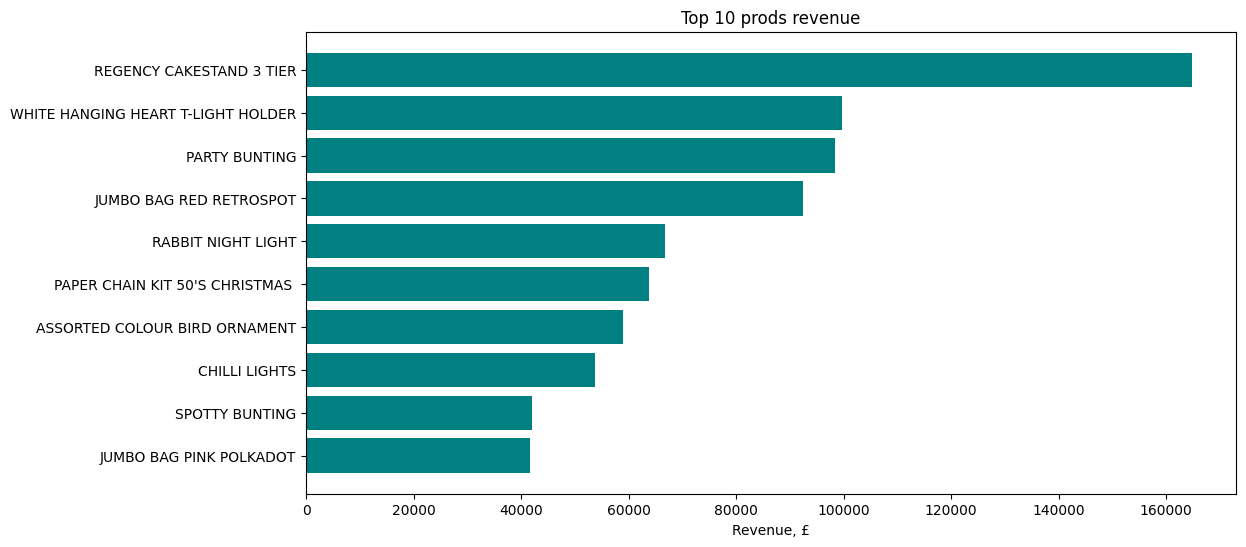

In [119]:
prods = top_prods['description'].head(10).copy()
sales = top_prods['revenue'].head(10).copy()
prods_sorted = sorted(zip(prods, sales), key=lambda x: x[1])
prods, sales = zip(*prods_sorted)
plt.figure(figsize=(12, 6))
plt.barh(prods, sales, color='teal')
plt.title('Top 10 prods revenue')
plt.xlabel('Revenue, £')
plt.ticklabel_format(axis='x', style='plain')
plt.show()

Распределение заказов

In [120]:
orders = df2.groupby('invoiceno')['revenue'].sum().reset_index()\
    .sort_values('revenue', ascending=False).reset_index()
orders.drop(columns=['index'], inplace=True)
print(orders.head())
print(orders.tail(), '\n')
print(orders['revenue'].mean())
print(orders['revenue'].median(), '\n')
print(orders['revenue'][orders['revenue'] > 0].mean())
print(orders['revenue'][orders['revenue'] > 0].median())

  invoiceno    revenue
0    581483  168469.60
1    541431   77183.60
2    574941   52940.94
3    576365   50653.91
4    556444   38970.00
      invoiceno    revenue
25292   C562375   -4345.10
25293   C570556  -11816.64
25294   C550456  -22998.40
25295   C541433  -77183.60
25296   C581484 -168469.60 

387.1124579989722
211.69 

519.4714019116977
302.59


In [121]:
print(df2[df2['invoiceno'] == 581483])
print(df2[df2['invoiceno'] == 'C581484'])

       invoiceno stockcode                  description  quantity  \
540421    581483     23843  PAPER CRAFT , LITTLE BIRDIE     80995   

               invoicedate  unitprice  customerid         country   revenue  \
540421 2011-12-09 09:15:00       2.08     16446.0  United Kingdom  168469.6   

           month  
540421  December  
       invoiceno stockcode                  description  quantity  \
540422   C581484     23843  PAPER CRAFT , LITTLE BIRDIE    -80995   

               invoicedate  unitprice  customerid         country   revenue  \
540422 2011-12-09 09:27:00       2.08     16446.0  United Kingdom -168469.6   

           month  
540422  December  


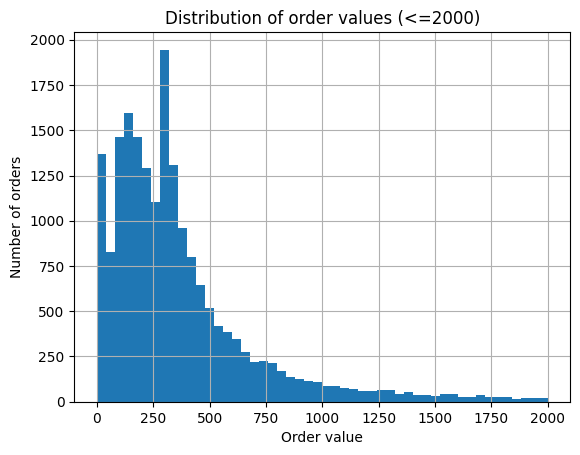

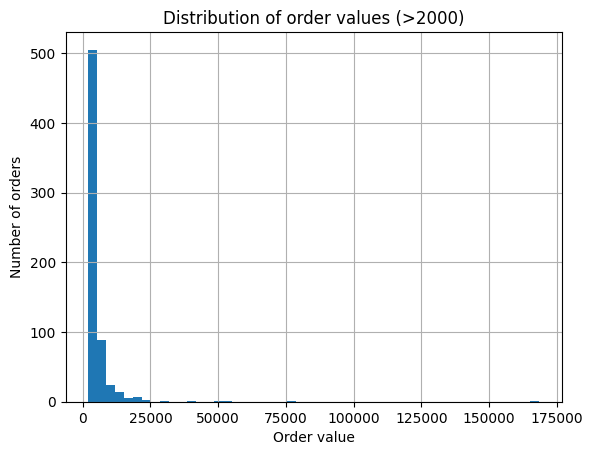

In [122]:
orders = orders[orders['revenue'] > 0]

orders[orders['revenue'] <= 2000].hist(bins=50)
plt.xlabel('Order value')
plt.ylabel('Number of orders')
plt.title('Distribution of order values (<=2000)')
plt.show()

orders[orders['revenue'] > 2000].hist(bins=50)
plt.xlabel('Order value')
plt.ylabel('Number of orders')
plt.title('Distribution of order values (>2000)')
plt.show()